# Kapasitet: hvor stor modell tåler 114 observasjoner?

Arbeidsverk 2, notebook 04. Bygger på notebook 02 (protokollen) og notebook 03
(trekkene, lekkasjetesten og den første ML-modellen).

Notebook 03 endte med to ting som pekte hit. Den ene var et funn: gradientboosting
slo referansen bare når den fikk regelverksregressorene, og hele fordelen forsvant
uten dem. Den andre var en påstand som falt — kryssæring over bydelene hjalp, i strid
med forhåndsregistreringen — og en forklaring på hvorfor, som ble notert som
**testbar og ikke testet**: at panelet virker som regularisering framfor som ny
informasjon.

Denne notebooken tester den forklaringen, og stiller samtidig spørsmålet den henger
sammen med: hvor mye modell tåler dette datagrunnlaget? Nevrale nett er verktøyet,
fordi kapasitet er noe man kan skru på der.

Modellene er skrevet i PyTorch, ikke fordi oppgaven krever et rammeverk, men fordi
den første kjøringen med et ferdig oppsett feilet stille. Avsnitt 4 forklarer.


## 1. Oppsett


In [1]:
import os, subprocess, sys

def git(*a, standard=None):
    try:
        return subprocess.run(["git", *a], capture_output=True, text=True,
                              check=True, cwd=REPO).stdout.strip()
    except Exception:
        return standard

REPO = "/content/bostotte-oslo" if os.path.isdir("/content/bostotte-oslo") else "."
if not os.path.isdir(os.path.join(REPO, "data")):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/Torcode/bostotte-oslo.git",
                    "/content/bostotte-oslo"], check=True)
    REPO = "/content/bostotte-oslo"
elif REPO.startswith("/content"):
    git("fetch", "--depth", "1", "origin", "main"); git("reset", "--hard", "origin/main")

try:
    import torch
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch"], check=True)
    import torch

COMMIT, UTTREKK = git("rev-parse", "--short", "HEAD", standard="ukjent"), "2026-08-04"
torch.set_num_threads(max(1, os.cpu_count() or 2))
print("repo    :", os.path.abspath(REPO))
print("commit  :", COMMIT)
print("uttrekk :", UTTREKK)
print("torch   :", torch.__version__, "|", torch.get_num_threads(), "traader")


repo    : /home/claude/bostotte-oslo
commit  : 00b040e
uttrekk : 2026-08-04
torch   : 2.13.0+cpu | 2 traader


In [2]:
# harmoni-med-git: denne cellen holdes utenfor sitt eget avtrykk
KILDEAVTRYKK = "ec93e1a0f07f5d03434cc630f43fe0ea31ca089ccbae321606e95bdfa24fb1ab"
FIL_MEG = "bostotte_04_kapasitet.ipynb"
RAATT = f"https://raw.githubusercontent.com/Torcode/bostotte-oslo/main/notebooks/{FIL_MEG}"
LOGG  = ("https://api.github.com/repos/Torcode/bostotte-oslo/commits"
         f"?path=notebooks/{FIL_MEG}&per_page=1")

import hashlib, json
import urllib.request, urllib.error

def kildeavtrykk(celler):
    ut = []
    for c in celler:
        kilde = c["source"] if isinstance(c["source"], str) else "".join(c["source"])
        if "harmoni-med-git" not in kilde:
            ut.append(kilde)
    return hashlib.sha256("\n".join(ut).encode("utf-8")).hexdigest()

def hent(url, sekunder=40):
    with urllib.request.urlopen(url, timeout=sekunder) as r:
        return json.load(r)

try:    NAAR = " (sist endret " + hent(LOGG)[0]["commit"]["committer"]["date"][:10] + ")"
except Exception: NAAR = ""

try:
    paa_main = kildeavtrykk(hent(RAATT)["cells"])
    MANIFEST_HARMONI = "i harmoni" if paa_main == KILDEAVTRYKK else "avvik mot main"
    print(f"I harmoni med main{NAAR}." if paa_main == KILDEAVTRYKK else
          f"AVVIK mot main. denne {KILDEAVTRYKK[:16]}..., main {paa_main[:16]}...{NAAR}")
except urllib.error.HTTPError as e:
    MANIFEST_HARMONI = "finnes ikke paa main" if e.code == 404 else f"HTTP {e.code}"
    print("Notebooken ligger ikke paa main ennaa." if e.code == 404
          else f"Kontrollen fikk HTTP {e.code}.")
except Exception as e:
    MANIFEST_HARMONI = f"ikke sjekket ({type(e).__name__})"
    print(f"Kontrollen naadde ikke GitHub ({type(e).__name__}).")


Notebooken ligger ikke paa main ennaa.


In [3]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import platform, importlib, time
import torch.nn as nn

RAW = os.path.join(REPO, "data/raw/")
FIL = "husbanken_bostotte_oslo_manedlig.csv"

def sha256(sti, blokk=1 << 20):
    h = hashlib.sha256()
    with open(sti, "rb") as f:
        for b in iter(lambda: f.read(blokk), b""):
            h.update(b)
    return h.hexdigest()

SJEKKSUM = sha256(RAW + FIL)
NB03 = ("https://raw.githubusercontent.com/Torcode/bostotte-oslo/"
        "main/notebooks/bostotte_03_trekk_og_trebasert.ipynb")

def manifest_fra_notebook(url, noekkel):
    nb = hent(url, 60)
    for celle in reversed(nb["cells"]):
        if celle["cell_type"] == "code" and noekkel in "".join(celle["source"]):
            for u in celle.get("outputs", []):
                if u.get("output_type") == "stream":
                    return json.loads("".join(u["text"]))
    raise LookupError("fant ikke manifestet")

try:
    M03 = manifest_fra_notebook(NB03, 'MANIFEST["resultat"]')
    assert M03["sjekksum"][FIL] == SJEKKSUM and M03["uttrekk"] == UTTREKK
    LENKE = "samme uttrekk og samme fil"
    NB03_RES = {k: v["MASE"] for k, v in M03["resultat"].items()}
    print("Notebook 03 paa main, samme uttrekk. MASE derfra:",
          ", ".join(f"{k} {v}" for k, v in NB03_RES.items() if k in ("M0", "G1", "G2")))
except Exception as e:
    LENKE, NB03_RES = f"ikke sjekket ({type(e).__name__})", {}
    print(f"Naadde ikke notebook 03 paa main ({type(e).__name__}).")

SEED = 20260807
np.random.seed(SEED)
pd.set_option("display.width", 130); pd.set_option("display.max_columns", 30)
SERIE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLEKK, BLEKK_2, DEMPET = "#0b0b0b", "#52514e", "#898781"
RUTE, BASIS = "#e1e0d9", "#c3c2b7"
HARDT = chr(160)
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130, "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.size": 8.5, "axes.titlesize": 9.5, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "text.color": BLEKK, "axes.labelcolor": BLEKK_2,
    "xtick.color": DEMPET, "ytick.color": DEMPET,
    "xtick.labelcolor": BLEKK_2, "ytick.labelcolor": BLEKK_2,
    "axes.edgecolor": BASIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": RUTE, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 7.5,
    "lines.linewidth": 1.6, "lines.solid_capstyle": "round"})

MANIFEST = {"commit": COMMIT, "uttrekk": UTTREKK, "python": platform.python_version(),
            "pakker": {}, "sjekksum": {FIL: SJEKKSUM}, "seed": SEED,
            "lenke_notebook03": LENKE}
for p in ["numpy", "pandas", "torch", "matplotlib"]:
    try:    MANIFEST["pakker"][p] = importlib.import_module(p).__version__
    except ImportError: MANIFEST["pakker"][p] = None
print("pakker:", MANIFEST["pakker"])


Notebook 03 paa main, samme uttrekk. MASE derfra: M0 1.003, G1 0.905, G2 0.815
pakker: {'numpy': '2.4.4', 'pandas': '3.0.2', 'torch': '2.13.0+cpu', 'matplotlib': '3.10.9'}


## 2. Protokollen, kontrollert for tredje gang


In [4]:
raa = pd.read_csv(RAW + FIL)
raa["dato"] = pd.to_datetime(dict(year=raa.aar, month=raa.manedsnr, day=1))
raa = raa.sort_values("dato").reset_index(drop=True)
kant = raa.index[(raa.dato == raa.dato.max()) & (raa.ant_husstander_termin == 0)]
est = raa.drop(index=kant)
est = est[est.dato >= "2017-01-01"].reset_index(drop=True)
M, N_EST = est.set_index("dato")["ant_husstander_termin"].astype(float), len(est)
LOG_M = np.log(M)
MIN_TRENING, H_MAKS = 72, 12
OPPRINNELSER = [est.dato.iloc[i-1] for i in range(1, N_EST+1)
                if MIN_TRENING <= i <= N_EST - H_MAKS]
NEVNER = {t0: np.abs(M.loc[:t0].values[12:] - M.loc[:t0].values[:-12]).mean()
          for t0 in OPPRINNELSER}
assert (len(OPPRINNELSER), N_EST) == (31, 114)

def maal(R, kol):
    e = R.sant - np.exp(R[kol])
    return pd.Series({"MASE": (e.abs()/R.q).mean(), "RMSE": np.sqrt((e**2).mean())})

kon = []
for t0 in OPPRINNELSER:
    tr = LOG_M.loc[:t0]
    for h in range(1, H_MAKS+1):
        m_ = t0 + pd.DateOffset(months=h)
        kon.append(dict(opprinnelse=t0, h=h, sant=M.loc[m_], q=NEVNER[t0],
                        M0=tr.iloc[-1],
                        M1=LOG_M.loc[m_ - pd.DateOffset(months=12*int(np.ceil(h/12)))]))
KON = pd.DataFrame(kon)
sjekk = {m: [round(float(maal(KON, m)["MASE"]), 3), round(float(maal(KON, m)["RMSE"]))]
         for m in ["M0", "M1"]}
FASIT = {"M0": [1.003, 1698], "M1": [1.228, 1844]}
assert sjekk == FASIT, f"protokollen avviker: {sjekk} mot {FASIT}"
NAIV = float(maal(KON, "M0")["MASE"])
print(f"Protokollen gir M0 {sjekk['M0']} og M1 {sjekk['M1']}, som i arbeidsverk 1.")
print(f"Naiv referanse: MASE {NAIV:.3f}.")


Protokollen gir M0 [1.003, 1698] og M1 [1.228, 1844], som i arbeidsverk 1.
Naiv referanse: MASE 1.003.


## 3. Forhåndsregistrering

Fire spørsmål, med begrunnelse.

**Q1 — Kapasitet hjelper ikke.** Zeng m.fl. (AAAI 2023) viser at ett lineært lag slår
flere transformer-varianter på standard prognosemålinger, altså på datasett som er
langt større enn dette. Med rundt tusen treningsrader og atten trekk skal derfor
kapasitetsstigen være flat eller fallende: den lineære modellen skal være
konkurransedyktig, og den bredeste skal overtilpasse. *Felles hvis MASE faller
monotont med bredden.*

**Q2 — Panelgevinsten er varians, ikke informasjon.** Notebook 03 forklarte at
kryssæring hjelper fordi femten bydeler gir flere eksempler på den samme
sammenhengen, ikke ny informasjon om Oslo. Følger den forklaringen, skal ytelsen
bedres med antall serier og **flate ut**. Og siden varians er problemet, skal
gevinsten være **størst for modellen med mest kapasitet**. *Felles hvis kurven ikke
flater ut, eller hvis den lineære modellen tjener mest på flere serier.*

**Q3 — Uten regelverket taper alt.** Som i notebook 03. *Felles hvis en variant uten
regelverksregressorene slår den naive referansen.*

**Q4 — Nett med skjulte lag slår ikke gradientboosting.** Notebook 03s beste variant
lå på 0,815. Med denne datamengden skal modellen med sterkest induktiv skjevhet
vinne, og et nett med skjulte lag har svakere skjevhet enn et tre-ensemble.
*Felles hvis et nett med skjulte lag kommer under 0,815.*

**Om rekkefølgen.** Spørsmålene er formulert før kjøringen, og de følger av notebook
01 og 03 pluss litteraturen. Men filen kan ikke bevise rekkefølgen: prosaen er
skrevet etter at tallene forelå. Fra notebook 05 legges forhåndsregistreringen inn i
en egen commit før kjøringen, slik at git-historikken bærer tidsstempelet. Det er en
reell svakhet ved denne notebooken og ved notebook 03, og den rettes framover framfor
å bortforklares.


## 4. En modell som feilet i stillhet

Første forsøk brukte `MLPRegressor` fra scikit-learn med standardiserte trekk og
utransformert mål. Kapasitetsstigen kom ut bakvendt: de smaleste nettene var klart
verst, og bare det bredeste var brukbart. Det så ut som et funn.

Det var det ikke. `MLPRegressor` stopper når tapet slutter å forbedre seg med mer enn
`tol`, som standard $10^{-4}$. Målvariabelen her er logvekst, med standardavvik rundt
0,09, så tapet starter rundt $10^{-3}$. Kriteriet slår inn etter tjue til femti
iterasjoner av femten hundre tillatte, og nettene rakk aldri å bli trent. Med
standardisert mål kjørte de samme nettene 68 til 292 iterasjoner og nådde en
treningstilpasning på 0,89 til 0,98.

Målestokken var altså ikke kapasitet, men hvor fort hvert nett ga opp. Det er en
tredje sort feil ved siden av de to som allerede er dokumentert i dette arbeidet — en
kalenderforveksling som ga feil fortegn på en konklusjon, og en kalibrering som fikk
se framtiden. Denne er verre enn begge, fordi et undertrent nett ikke gir feilmelding
og ikke gir urimelige tall.

Derfor er modellene her skrevet i PyTorch med **fast antall epoker og full batch**.
Det er en tregere måte å trene på, men det finnes ikke noe stoppkriterium som kan slå
inn uten at det står i koden. Treningstilpasningen rapporteres ved siden av
prognosefeilen, slik at det er synlig om et nett har lært noe i det hele tatt.


## 5. Trekk, buffer og lekkasjetest

Trekkene er de samme som i notebook 03. Én ting er ny: siden det nå kjøres tusenvis
av tilpasninger, bufres de historiske trekkene én gang per serie i stedet for å
regnes på nytt for hver opprinnelse. Bufferet er lovlig fordi et trekk for kildemåned
$s$ bare avhenger av $s$ — ikke av hvilken opprinnelse det senere brukes ved.

Det er en påstand om koden, og den testes: cellen under sammenlikner hver bufret rad
mot en rad regnet fra bunnen på en avkortet serie.


In [5]:
mnd_alle = pd.date_range("2010-01-01", "2027-12-01", freq="MS")
X = pd.DataFrame(index=mnd_alle)
X["win_covid"] = ((mnd_alle >= "2020-04-01") & (mnd_alle <= "2020-10-01")).astype(int)
X["win_strom"] = ((mnd_alle >= "2021-12-01") & (mnd_alle <= "2024-03-01")).astype(int)
X["pakke_2024h2"] = (((mnd_alle >= "2024-07-01").astype(int)
                      + (mnd_alle >= "2024-09-01").astype(int)
                      + (mnd_alle >= "2024-10-01").astype(int)) / 3)

def u_av_fase(fase=0, fra=pd.Timestamp("2010-01-01"), til=pd.Timestamp("2027-12-31")):
    anker = pd.Timestamp("2014-01-06") + pd.Timedelta(days=fase)
    start = anker - pd.Timedelta(days=14*int(np.ceil((anker - fra).days/14)))
    d = pd.date_range(start, til, freq="14D"); d = d[d >= fra]
    return pd.Series(d).dt.to_period("M").dt.to_timestamp().value_counts().sort_index()

u = u_av_fase().reindex(mnd_alle)
X["k_pre"]  = (u - 26/12) * (mnd_alle <= "2024-12-01").astype(int)
X["k_post"] = (u - 26/12) * (mnd_alle >= "2025-01-01").astype(int)
REG, MIN_NZ, LAG = list(X.columns), 6, [1, 2, 3, 6, 11, 12]

def trekk(serie, s):
    v = serie.loc[:s]
    if len(v) < 13:
        return None
    d = np.diff(np.log(v.values))
    ut = {f"lag{l}": np.log(v.iloc[-1-l]) - np.log(v.iloc[-1]) for l in LAG}
    ut["niva"] = np.log(v.iloc[-1]); ut["d1"] = d[-1]
    ut["d12"] = np.log(v.iloc[-1]) - np.log(v.iloc[-13])
    ut["sd6"] = d[-6:].std(); ut["sd12"] = d[-12:].std(); ut["snitt6"] = d[-6:].mean()
    return ut

def historikk(serie):
    r = {s: trekk(serie, s) for s in serie.index}
    return pd.DataFrame({s: v for s, v in r.items() if v is not None}).T

byd = pd.read_csv(RAW + "husbanken_bostotte_oslo_bydel_manedlig.csv",
                  dtype={"kommunenr": str})
byd["dato"] = pd.to_datetime(dict(year=byd.aar, month=byd.manedsnr, day=1))
byd = byd[byd.ant_husstander_termin > 0]
PANEL = {k: g.set_index("dato")["ant_husstander_termin"].astype(float).sort_index()
         for k, g in byd.groupby("kommunenr") if k != "0301"}
PANEL = {k: v[v.index >= "2017-01-01"] for k, v in PANEL.items()}
SERIER = {"OSLO": M, **PANEL}
# Fast rekkefoelge, storste bydel foerst, saa laeringskurven er reproduserbar.
REKKE = ["OSLO"] + sorted(PANEL, key=lambda k: -PANEL[k].iloc[-1])
HIST = {k: historikk(v) for k, v in SERIER.items()}
KOL_H = list(HIST["OSLO"].columns)
KOL = KOL_H + ["mnd"] + REG

# Lekkasjetest: bufret rad mot rad regnet fra bunnen paa en avkortet serie.
AVVIK = []
for navn in ["OSLO", REKKE[1], REKKE[-1]]:
    s = SERIER[navn]
    for kilde in HIST[navn].index[::9]:
        fersk = trekk(s.loc[:kilde], kilde)
        for k, v in fersk.items():
            if not np.isclose(v, HIST[navn].loc[kilde, k], rtol=0, atol=0):
                AVVIK.append((navn, f"{kilde:%Y-%m}", k))
assert not AVVIK, f"bufferet avviker fra ferske trekk: {AVVIK[:3]}"
print(f"{len(SERIER)} serier bufret. Lekkasjetest paa 3 av dem: {len(AVVIK)} avvik.")
print(f"{len(KOL)} trekk: {len(KOL_H)} historiske + maanedsnummer + {len(REG)} regressorer")


16 serier bufret. Lekkasjetest paa 3 av dem: 0 avvik.
18 trekk: 12 historiske + maanedsnummer + 5 regressorer


## 6. Modellene

Fire kapasitetsnivåer, alle trent likt: full batch, 400 epoker, Adam med
læringsrate 0,01 og vektnedbrytning $10^{-4}$. Trekk og mål standardiseres inne i
hvert treningsvindu, aldri på tvers av det.

| Id | Arkitektur | Parametre ved 18 trekk |
|---|---|---|
| L0 | ett lineært lag | 19 |
| N8 | 18 → 8 → 1, ReLU | 161 |
| N32 | 18 → 32 → 32 → 1, ReLU | 1 697 |
| N128 | 18 → 128 → 128 → 1, ReLU | 19 073 |

Den nederste raden er poenget: N128 har flere parametre enn treningssettet har rader.


In [6]:
def sett(navn, t0, h, aktive):
    s, hh = SERIER[navn], HIST[navn]
    kilder = hh.index[hh.index + pd.DateOffset(months=h) <= t0]
    kilder = kilder[[k + pd.DateOffset(months=h) in s.index for k in kilder]]
    if len(kilder) == 0:
        return None, None
    maalmnd = kilder + pd.DateOffset(months=h)
    D = hh.loc[kilder].copy()
    D["mnd"] = maalmnd.month
    for r in REG:
        D[r] = X.loc[maalmnd, r].values if r in aktive else 0.0
    y = np.log(s.loc[maalmnd].values) - np.log(s.loc[kilder].values)
    return D[KOL].to_numpy(dtype=float), y

def prediksjonsrad(t0, h, aktive):
    m_ = t0 + pd.DateOffset(months=h)
    d = HIST["OSLO"].loc[[t0]].copy()
    d["mnd"] = m_.month
    for r in REG:
        d[r] = X.loc[m_, r] if r in aktive else 0.0
    return d[KOL].to_numpy(dtype=float)

def globalt(n, t0, h, aktive):
    Xs, ys = [], []
    for navn in REKKE[:n]:
        a, b = sett(navn, t0, h, aktive)
        if a is not None:
            Xs.append(a); ys.append(b)
    return np.vstack(Xs), np.concatenate(ys)

def arkitektur(d_inn, bredde, dybde):
    if dybde == 0:
        return nn.Linear(d_inn, 1)
    lag = [nn.Linear(d_inn, bredde), nn.ReLU()]
    for _ in range(dybde - 1):
        lag += [nn.Linear(bredde, bredde), nn.ReLU()]
    return nn.Sequential(*lag, nn.Linear(bredde, 1))

EPOKER, LR, WD = 400, 1e-2, 1e-4

def tren(Xg, yg, Xpr, bredde, dybde):
    mx, sx = Xg.mean(0), Xg.std(0) + 1e-9
    my, sy = yg.mean(), yg.std() + 1e-9
    Xn = torch.tensor((Xg - mx)/sx, dtype=torch.float32)
    yn = torch.tensor((yg - my)/sy, dtype=torch.float32).view(-1, 1)
    Pn = torch.tensor((Xpr - mx)/sx, dtype=torch.float32)
    torch.manual_seed(SEED)
    m = arkitektur(Xn.shape[1], bredde, dybde)
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=WD)
    tapfn = nn.MSELoss()
    for _ in range(EPOKER):
        opt.zero_grad(); tap = tapfn(m(Xn), yn); tap.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        return float(m(Pn)[0, 0])*sy + my, 1 - float(tap)

STIGE = {"L0": (0, 0), "N8": (8, 1), "N32": (32, 2), "N128": (128, 2)}
KURVE = [1, 2, 4, 8, 16]
for navn, (b, d) in STIGE.items():
    m = arkitektur(len(KOL), b, d)
    print(f"  {navn:5s} {sum(p.numel() for p in m.parameters()):6d} parametre")


  L0        19 parametre
  N8       161 parametre
  N32     1697 parametre
  N128   19073 parametre


Kjøringen under gjør 14 tilpasninger per prognosepunkt: fire kapasitetsnivåer, fire
panelstørrelser i to modellklasser, og to ablasjoner. Med 372 punkter blir det 5 208
tilpasninger. **Cellen tar rundt tjue minutter.**


In [7]:
t_start, rader, TRENING = time.time(), [], []
for t0 in OPPRINNELSER:
    aktive = [r for r in REG if (X.loc[M.loc[:t0].index, r] != 0).sum() >= MIN_NZ]
    for h in range(1, H_MAKS + 1):
        m_ = t0 + pd.DateOffset(months=h)
        Xpr, Xpu = prediksjonsrad(t0, h, aktive), prediksjonsrad(t0, h, [])
        ankpr = LOG_M.loc[t0]
        rk = dict(opprinnelse=t0, h=h, dato=m_, sant=M.loc[m_], q=NEVNER[t0])

        Xg, yg = globalt(16, t0, h, aktive)
        rk["n_rader"] = len(Xg)
        for navn, (b, d) in STIGE.items():
            p, r2 = tren(Xg, yg, Xpr, b, d)
            rk[navn] = ankpr + p
            TRENING.append(dict(modell=navn, r2=r2))
            if navn == "L0":  TRENING.append(dict(modell="L16", r2=r2))
            if navn == "N32": TRENING.append(dict(modell="K16", r2=r2))

        for n in KURVE:
            if n == 16:
                rk["K16"], rk["L16"] = rk["N32"], rk["L0"]
                continue
            Xn_, yn_ = globalt(n, t0, h, aktive)
            pk, r2k = tren(Xn_, yn_, Xpr, 32, 2)
            pl, r2l = tren(Xn_, yn_, Xpr, 0, 0)
            rk[f"K{n}"], rk[f"L{n}"] = ankpr + pk, ankpr + pl
            TRENING.append(dict(modell=f"K{n}", r2=r2k))
            TRENING.append(dict(modell=f"L{n}", r2=r2l))

        Xu, yu = globalt(16, t0, h, [])
        rk["N32u"] = ankpr + tren(Xu, yu, Xpu, 32, 2)[0]
        rk["L0u"]  = ankpr + tren(Xu, yu, Xpu, 0, 0)[0]
        rader.append(rk)

R = pd.DataFrame(rader)
TR = pd.DataFrame(TRENING).groupby("modell").r2.mean()
print(f"{len(R)} prognosepunkter, {14*len(R)} tilpasninger, {time.time()-t_start:.0f} s")
print(f"treningsrader per tilpasning paa hele panelet: {R.n_rader.min()}-{R.n_rader.max()}")


372 prognosepunkter, 5208 tilpasninger, 1295 s
treningsrader per tilpasning paa hele panelet: 768-1424


## 7. Q1: kapasitetsstigen

Tabellen setter treningstilpasningen ved siden av prognosefeilen. Den første sier hvor
godt modellen forklarer det den har sett, den andre hvor godt den treffer det den
ikke har sett.


In [8]:
stige = pd.DataFrame({
    "parametre": [sum(p.numel() for p in arkitektur(len(KOL), b, d).parameters())
                  for b, d in STIGE.values()],
    "R2 trening": [TR[k] for k in STIGE],
    "MASE": [maal(R, k)["MASE"] for k in STIGE],
    "RMSE": [maal(R, k)["RMSE"] for k in STIGE]},
    index=list(STIGE)).round({"R2 trening": 3, "MASE": 3, "RMSE": 0})
stige.index.name = None
print(f"Naiv referanse: MASE {NAIV:.3f}. Beste i notebook 03: "
      f"{NB03_RES.get('G2', float('nan')):.3f}.\n")
stige


Naiv referanse: MASE 1.003. Beste i notebook 03: 0.815.



,parametre,R2 trening,MASE,RMSE
L0,19,0.650,0.767,1308.0
N8,161,0.872,0.898,1584.0
N32,1697,0.963,0.964,1647.0
N128,19073,0.989,0.939,1596.0


Stigen er entydig, og den peker feil vei for alle som håper kapasitet er svaret.
Modellen med nitten parametre har lavest prognosefeil. Modellen med nitten tusen har
høyest treningstilpasning. De to kolonnene løper motsatt vei: R² på
treningssettet stiger fra 0,65 til 0,99, mens MASE stiger fra 0,767 til 0,964. Bare
det siste steget bryter mønsteret — N128 ligger marginalt bedre enn N32 — så
rekkefølgen er ikke helt monoton, men retningen er utvetydig.

Det er overtilpasning målt, ikke antatt. N128 har flere parametre enn treningssettet
har rader og klarer å forklare nesten alt den har sett; nettopp derfor bærer den med
seg støy inn i prognosen. **Q1 holdt.**

Verdt å stanse ved: 0,767 er den laveste MASE i hele prosjektet. Lavere enn
gradientboosting i notebook 03 (0,815), lavere enn M5 (0,867), og lavere enn M7
(0,838), som får pålagt en koeffisient estimert på hele utvalget. Også på RMSE, der
G2 tapte mot M7, ligger den lineære modellen først. Den beste modellen i arbeidet er
altså en regresjon med atten forklaringsvariabler, tilpasset på et panel.


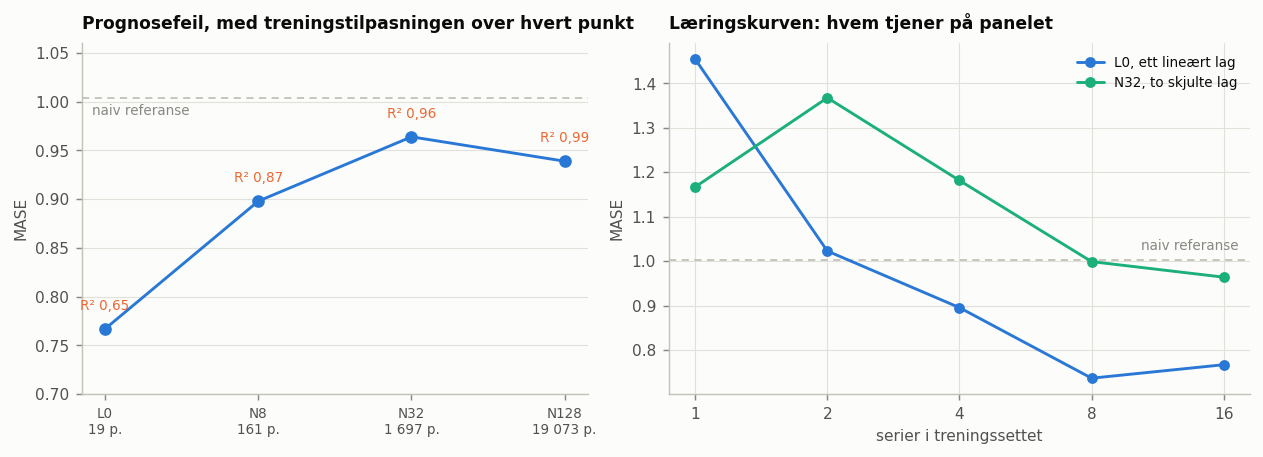

In [9]:
fig, akser = plt.subplots(1, 2, figsize=(9.6, 3.4), layout="constrained",
                          gridspec_kw={"width_ratios": [1, 1.15]})
xp = np.arange(len(stige))

ax = akser[0]
ax.plot(xp, stige["MASE"], color=SERIE[0], marker="o", ms=6, zorder=3)
for i, (m_, r_) in enumerate(zip(stige.MASE, stige["R2 trening"])):
    ax.annotate(f"R² {r_:.2f}".replace(".", ","), xy=(i, m_), xytext=(0, 9),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=7.5, color=SERIE[1])
ax.axhline(NAIV, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.annotate("naiv referanse", xy=(0.02, NAIV), xycoords=("axes fraction", "data"),
            xytext=(0, -3), textcoords="offset points", ha="left", va="top",
            fontsize=7.5, color=DEMPET)
ax.set_xticks(xp, [f"{k}\n{p:,}".replace(",", HARDT) + " p."
                   for k, p in zip(stige.index, stige.parametre)], fontsize=7.5)
ax.set_ylim(0.70, 1.06)
ax.set_ylabel("MASE")
ax.set_title("Prognosefeil, med treningstilpasningen over hvert punkt")
ax.grid(axis="x", visible=False)

ax = akser[1]
ax.plot(KURVE, [maal(R, f"L{n}")["MASE"] for n in KURVE],
        color=SERIE[0], marker="o", ms=5, label="L0, ett lineært lag")
ax.plot(KURVE, [maal(R, f"K{n}")["MASE"] for n in KURVE],
        color=SERIE[2], marker="o", ms=5, label="N32, to skjulte lag")
ax.axhline(NAIV, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.annotate("naiv referanse", xy=(0.98, NAIV), xycoords=("axes fraction", "data"),
            xytext=(0, 4), textcoords="offset points", ha="right", va="bottom",
            fontsize=7.5, color=DEMPET)
ax.set_xscale("log", base=2); ax.set_xticks(KURVE, [str(n) for n in KURVE])
ax.set_xlabel("serier i treningssettet"); ax.set_ylabel("MASE")
ax.set_title("Læringskurven: hvem tjener på panelet")
ax.legend(loc="upper right")
plt.show()


Venstre rute er stigen. Høyre rute er læringskurven, som avsnittet under leser.

## 8. Q2: hvem tjener på panelet


In [10]:
kurve = pd.DataFrame({
    "rader": [len(globalt(n, OPPRINNELSER[-1], 6, REG)[1]) for n in KURVE],
    "MASE L0": [maal(R, f"L{n}")["MASE"] for n in KURVE],
    "R2 trening L0": [TR[f"L{n}"] for n in KURVE],
    "MASE N32": [maal(R, f"K{n}")["MASE"] for n in KURVE],
    "R2 trening N32": [TR[f"K{n}"] for n in KURVE],
}, index=pd.Index(KURVE, name="serier")).round(3)
kurve["gevinst L0"]  = (kurve["MASE L0"].iloc[0] - kurve["MASE L0"]).round(3)
kurve["gevinst N32"] = (kurve["MASE N32"].iloc[0] - kurve["MASE N32"]).round(3)
kurve


,rader,MASE L0,R2 trening L0,MASE N32,R2 trening N32,gevinst L0,gevinst N32
serier,,,,,,,
1,84,1.454,0.843,1.167,1.000,0.000,0.000
2,168,1.023,0.718,1.368,1.000,0.431,-0.201
4,336,0.896,0.694,1.182,0.998,0.558,-0.015
8,672,0.737,0.678,0.999,0.989,0.717,0.168
16,1344,0.767,0.650,0.964,0.963,0.687,0.203


Første del av Q2 holdt. Kurven for den lineære modellen faller kraftig fra én til
åtte serier og flater deretter ut — siste steg går til og med marginalt feil vei,
fra 0,737 til 0,767. Mer panel gir ikke mer.

Andre del falt, og den falt tydelig. Jeg registrerte at gevinsten skulle være størst
for modellen med mest kapasitet, siden varians var forklaringen. Det motsatte skjedde:
den lineære modellen forbedret seg 0,69 fra én til seksten serier, nettet med to
skjulte lag bare 0,20. Og rangeringen snur mellom én og to serier — med bare
Oslo-serien er nettet best.

Kolonnene med treningstilpasning viser hvorfor forklaringen min var for grov. Med én
serie har nettet 84 rader og 1 697 parametre, og forklarer treningssettet **fullt
ut**: R² 1,000. Det gjør det fortsatt ved 1 344 rader, med 0,963. Nettet
interpolerer uansett hvor mye data det får, så mer panel endrer lite for det.

Den lineære modellen går motsatt vei. Ved én serie forklarer den 0,84 av
treningssettet; ved seksten 0,65. Den slutter altså å kunne tilpasse seg støyen, og
det er nettopp da prognosefeilen faller — fra 1,454 til 0,737.

Panelet gjør derfor ikke først og fremst en fleksibel modell mer stabil. Det gjør en
enkel modell **identifiserbar**. Nitten koeffisienter lar seg ikke feste med 84
observasjoner, og lar seg feste med 672.

Det er en presisering av notebook 03, ikke en tilbaketrekking: kryssæring virker
gjennom varians, som antatt der. Men den virker sterkest der modellen er enkel nok
til at variansreduksjonen faktisk oversettes til treffsikkerhet.


In [11]:
def dm_harvey(R, a, b, h):
    x = R[R.h == h]
    e1 = (x.sant - np.exp(x[a])).values
    e2 = (x.sant - np.exp(x[b])).values
    n = len(e1); d = e1**2 - e2**2
    dc = d - d.mean()
    gamma = np.array([(dc[:n-k]*dc[k:]).sum()/n for k in range(h)])
    v = (gamma[0] + 2*gamma[1:].sum())/n
    if not np.isfinite(v) or v <= 0:
        return np.nan
    return (d.mean()/np.sqrt(v)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)

PAR = [("N8", "L0"), ("N32", "L0"), ("N128", "L0"), ("L1", "L8"), ("K1", "K16")]
dm = pd.DataFrame({f"{a} mot {b}": [dm_harvey(R, a, b, h) for h in [1, 3, 6, 12]]
                   for a, b in PAR}, index=pd.Index([1, 3, 6, 12], name="h")).round(2)
print("Positiv verdi favoriserer modellen som staar sist. Ensidig kritisk verdi: 1,64.\n")
dm.T


Positiv verdi favoriserer modellen som staar sist. Ensidig kritisk verdi: 1,64.



h,1,3,6,12
N8 mot L0,2.79,1.37,1.26,-1.14
N32 mot L0,-0.15,1.80,1.14,2.33
N128 mot L0,1.18,2.46,1.68,1.80
L1 mot L8,0.85,1.43,1.53,2.04
K1 mot K16,1.17,0.77,1.04,-1.10


Testene bekrefter det tabellene viser, men bare delvis. Den lineære modellen slår
N128 med statistikk over 1,64 på tre av fire horisonter, og N8 klart ved h = 1. For
læringskurven passerer den lineære modellen fra én til åtte serier ved h = 12, mens
nettets tilsvarende forbedring ikke passerer på noen horisont. Med 31 opprinnelser
er dette omtrent så mye oppløsning materialet har.

## 9. Q3: ablasjonen


In [12]:
abl = pd.DataFrame({
    "med regelverk":  [maal(R, m)["MASE"] for m in ["L0", "N32"]],
    "uten regelverk": [maal(R, m)["MASE"] for m in ["L0u", "N32u"]],
}, index=["L0 lineaer", "N32 to skjulte lag"]).round(3)
abl["naiv referanse"] = round(NAIV, 3)
abl.index.name = None
abl


,med regelverk,uten regelverk,naiv referanse
L0 lineaer,0.767,1.498,1.003
N32 to skjulte lag,0.964,1.546,1.003


Uten regelverksregressorene faller begge modellene til rundt 1,5 — halvannen gang
verre enn å gjenta siste observerte verdi. Det er samme bilde som i notebook 03, og
nå med en annen modellfamilie. **Q3 holdt.**

Det er også det viktigste enkeltresultatet i arbeidsverk 2, og det er verdt å si rett
ut: hverken trebaserte modeller eller nevrale nett finner noe i denne serien på egen
hånd. Det som virker, er daterte regelendringer — som er domenekunnskap, ikke
læring. Modellklassen avgjør hvor godt den kunnskapen forvaltes, og der er en
lineær spesifikasjon best.

## 10. Oppgjør


In [13]:
best_nett = min(maal(R, m)["MASE"] for m in ["N8", "N32", "N128"])
oppgjor = pd.DataFrame([
    ["Q1", "Kapasitet hjelper ikke",
     f"L0 {maal(R,'L0')['MASE']:.3f} mot N128 {maal(R,'N128')['MASE']:.3f}", "holdt"],
    ["Q2a", "Kurven flater ut",
     f"L0 {maal(R,'L1')['MASE']:.3f} -> {maal(R,'L8')['MASE']:.3f} -> "
     f"{maal(R,'L16')['MASE']:.3f}", "holdt"],
    ["Q2b", "Gevinsten stoerst for mest kapasitet",
     f"gevinst L0 {maal(R,'L1')['MASE']-maal(R,'L16')['MASE']:+.3f}, "
     f"N32 {maal(R,'K1')['MASE']-maal(R,'K16')['MASE']:+.3f}", "FALT"],
    ["Q3", "Uten regelverket taper alt",
     f"L0u {maal(R,'L0u')['MASE']:.3f}, N32u {maal(R,'N32u')['MASE']:.3f}, "
     f"naiv {NAIV:.3f}", "holdt"],
    ["Q4", "Skjulte lag slaar ikke gradientboosting",
     f"beste nett med skjulte lag {best_nett:.3f} mot G2 "
     f"{NB03_RES.get('G2', float('nan')):.3f}", "holdt"],
], columns=["", "spoersmaal", "maalt", "utfall"]).set_index("")
oppgjor


,spoersmaal,maalt,utfall
,,,
Q1,Kapasitet hjelper ikke,L0 0.767 mot N128 0.939,holdt
Q2a,Kurven flater ut,L0 1.454 -> 0.737 -> 0.767,holdt
Q2b,Gevinsten stoerst for mest kapasitet,"gevinst L0 +0.687, N32 +0.203",FALT
Q3,Uten regelverket taper alt,"L0u 1.498, N32u 1.546, naiv 1.003",holdt
Q4,Skjulte lag slaar ikke gradientboosting,beste nett med skjulte lag 0.898 mot G2 0.815,holdt


In [14]:
alle = pd.DataFrame(
    [["L0 ett lineaert lag (denne)", maal(R, "L0")["MASE"], maal(R, "L0")["RMSE"]],
     ["G2 gradientboosting global (nb 03)", NB03_RES.get("G2", np.nan), 1408],
     ["M7 M6 + paalagt bidrag (arbeidsverk 1)", 0.838, 1322],
     ["M5 RegARIMA + X (arbeidsverk 1)", 0.867, 1391],
     ["N8 ett skjult lag (denne)", maal(R, "N8")["MASE"], maal(R, "N8")["RMSE"]],
     ["M2 ETS (arbeidsverk 1)", 0.931, 1565],
     ["N128 to skjulte lag (denne)", maal(R, "N128")["MASE"], maal(R, "N128")["RMSE"]],
     ["N32 to skjulte lag (denne)", maal(R, "N32")["MASE"], maal(R, "N32")["RMSE"]],
     ["M6 RegARIMA + X + k (arbeidsverk 1)", 0.967, 1525],
     ["M0 naiv (kontrollert)", NAIV, 1698]],
    columns=["modell", "MASE", "RMSE"]).sort_values("MASE")
alle["MASE"] = alle.MASE.round(3); alle["RMSE"] = alle.RMSE.round(0)
alle.set_index("modell", inplace=True); alle.index.name = None
alle


,MASE,RMSE
L0 ett lineaert lag (denne),0.767,1308.0
G2 gradientboosting global (nb 03),0.815,1408.0
M7 M6 + paalagt bidrag (arbeidsverk 1),0.838,1322.0
M5 RegARIMA + X (arbeidsverk 1),0.867,1391.0
N8 ett skjult lag (denne),0.898,1584.0
M2 ETS (arbeidsverk 1),0.931,1565.0
N128 to skjulte lag (denne),0.939,1596.0
N32 to skjulte lag (denne),0.964,1647.0
M6 RegARIMA + X + k (arbeidsverk 1),0.967,1525.0
M0 naiv (kontrollert),1.003,1698.0


Fire av fem holdt. Den som falt, falt på samme måte som i notebook 03: begrunnelsen
var riktig i retning og feil i styrke, og målingen rettet den.

Samlet rangering av alt som er kjørt i de to arbeidsverkene står i tabellen over.
Den skal leses med to forbehold. Radene merket arbeidsverk 1 er avskrift og ikke
uavhengig kontrollert her, bortsett fra M0. Og ingen av forskjellene i toppen av
tabellen er store nok til å skilles fra tilfeldighet med 31 opprinnelser — det som
*er* skilt fra tilfeldighet, er avstanden mellom kapasitetsnivåene innad i denne
notebooken, og avstanden ned til modellene uten regelverk.

**Hva notebook 05 arver.** Hierarkisk avstemming mot bydelspanelet, og intervaller:
alle modellene i notebook 03 og 04 gir punktprognoser, så dekning og intervallskår
mangler for dem. Det tidsgyldige konformale skjemaet fra notebook 02 er veien dit.

**Og en endring i arbeidsformen.** Forhåndsregistreringen for notebook 05 legges inn
i en egen commit før kjøringen starter, slik at git-historikken bærer tidsstempelet.
Slik det er nå, hviler rekkefølgen på at jeg sier den.

### Kjøremanifest


In [15]:
MANIFEST["kapasitet"] = {k: {"parametre": int(stige.parametre[k]),
                             "r2_trening": round(float(stige["R2 trening"][k]), 3),
                             "MASE": round(float(stige.MASE[k]), 3)} for k in STIGE}
MANIFEST["laeringskurve"] = {
    "lineaer": {str(n): round(float(maal(R, f"L{n}")["MASE"]), 3) for n in KURVE},
    "nett32":  {str(n): round(float(maal(R, f"K{n}")["MASE"]), 3) for n in KURVE}}
MANIFEST["ablasjon"] = {"L0_uten_regelverk": round(float(maal(R, "L0u")["MASE"]), 3),
                        "N32_uten_regelverk": round(float(maal(R, "N32u")["MASE"]), 3),
                        "naiv": round(NAIV, 3)}
MANIFEST["forhaandsregistrering"] = {"Q1": "holdt", "Q2a": "holdt", "Q2b": "falt",
                                     "Q3": "holdt", "Q4": "holdt"}
MANIFEST["kontroller"] = {
    "protokoll_mot_arbeidsverk1": "M0 og M1 like",
    "lekkasjetest_buffer": f"{len(AVVIK)} avvik",
    "harmoni_med_main": MANIFEST_HARMONI,
    "lenke_notebook03": LENKE}
print(json.dumps(MANIFEST, indent=2, ensure_ascii=False))


{
  "commit": "00b040e",
  "uttrekk": "2026-08-04",
  "python": "3.11.15",
  "pakker": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "torch": "2.13.0+cpu",
    "matplotlib": "3.10.9"
  },
  "sjekksum": {
    "husbanken_bostotte_oslo_manedlig.csv": "5e741e0864bd8d666057b627170ebf0b47229ea846f0ed98717cc5bc590600d6"
  },
  "seed": 20260807,
  "lenke_notebook03": "samme uttrekk og samme fil",
  "kapasitet": {
    "L0": {
      "parametre": 19,
      "r2_trening": 0.65,
      "MASE": 0.767
    },
    "N8": {
      "parametre": 161,
      "r2_trening": 0.872,
      "MASE": 0.898
    },
    "N32": {
      "parametre": 1697,
      "r2_trening": 0.963,
      "MASE": 0.964
    },
    "N128": {
      "parametre": 19073,
      "r2_trening": 0.989,
      "MASE": 0.939
    }
  },
  "laeringskurve": {
    "lineaer": {
      "1": 1.454,
      "2": 1.023,
      "4": 0.896,
      "8": 0.737,
      "16": 0.767
    },
    "nett32": {
      "1": 1.167,
      "2": 1.368,
      "4": 1.182,
      "8": 0.